In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

## 1. Imports and Model Loading

In [2]:
import sys
import os

parent_dir = os.path.dirname(os.getcwd()) 
sys.path.insert(0, parent_dir)

from utils import (
    setup_sam_3d_body, setup_visualizer, 
    visualize_2d_results, visualize_3d_mesh, save_mesh_results, 
    display_results_grid, process_image_with_mask
)

# Set up SAM 3D Body estimator
estimator = setup_sam_3d_body(hf_repo_id="facebook/sam-3d-body-dinov3")
# Set up visualizer
visualizer = setup_visualizer()

/home/diego/SAM-mesh/sam-3d-body/sam_3d_body/models/heads/mhr_head.py:33: UserWarning: Momentum is not enabled
  warnings.warn("Momentum is not enabled")


Loading SAM 3D Body model from facebook/sam-3d-body-dinov3...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading SAM 3D Body model...


Using cache found in /home/diego/.cache/torch/hub/facebookresearch_dinov3_main
Ignored kwargs: {'drop_path': 0.1}
The model and loaded state dict do not match exactly

missing keys in source state_dict: backbone.encoder.mask_token, head_pose.hand_pose_comps_ori, head_pose.mhr.face_expressions_model.shape_vectors, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.0.sparse_indices, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.0.sparse_weight, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.2.weight, head_pose.mhr.character_torch.skeleton.joint_translation_offsets, head_pose.mhr.character_torch.skeleton.joint_prerotations, head_pose.mhr.character_torch.skeleton.pmi, head_pose.mhr.character_torch.skeleton.joint_parents, head_pose.mhr.character_torch.mesh.rest_vertices, head_pose.mhr.character_torch.mesh.faces, head_pose.mhr.character_torch.mesh.texcoords, head_pose.mhr.character_torch.mesh.texcoord_faces, head_pose.mhr.character_torch.parameter_transform.paramet

Loading human detector from vitdet...
########### Using human detector: ViTDet...


/home/diego/SAM-mesh/venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loading FOV estimator from moge2...
########### Using fov estimator: MoGe2...
Mask-condition inference is not supported...
Setup complete!
  Human detector: ✓
  Human segmentor: ✗ (mask inference disabled)
  FOV estimator: ✓


## 2. Process Image and Get Outputs

Processing image with SAM 3D Body...
Running object detector...


/home/diego/SAM-mesh/venv/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Found boxes: [[ 431.62875  868.0243   621.28766 1208.4767 ]
 [ 736.48334  742.3608   879.90405 1013.5494 ]]
Running FOV estimator ...
Number of people detected: 2
Output keys for first person: ['bbox', 'focal_length', 'pred_keypoints_3d', 'pred_keypoints_2d', 'pred_vertices', 'pred_cam_t', 'pred_pose_raw', 'global_rot', 'body_pose_params', 'hand_pose_params', 'scale_params', 'shape_params', 'expr_params', 'mask', 'pred_joint_coords', 'pred_global_rots', 'lhand_bbox', 'rhand_bbox']


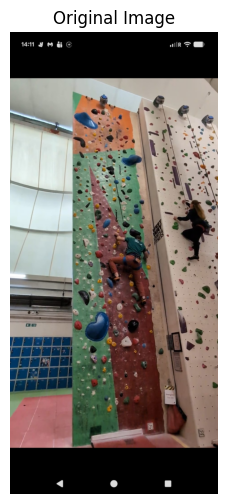

In [3]:
import cv2
import matplotlib.pyplot as plt

# Load and process the image
image_path = "images/diego.jpeg"  # Relative to notebook folder
img_cv2 = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)

# Process the image with SAM 3D Body
print("Processing image with SAM 3D Body...")
outputs = estimator.process_one_image(image_path)

print(f"Number of people detected: {len(outputs)}")
print(f"Output keys for first person: {list(outputs[0].keys()) if outputs else 'No people detected'}")

# Display the original image
plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Original Image')
plt.show()

## 3. 2D Visualization - Keypoints and Bounding Boxes

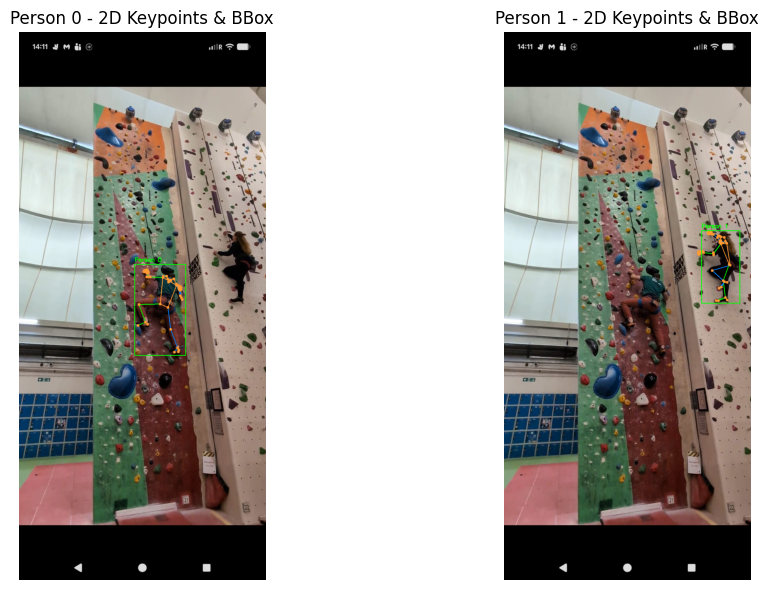

In [4]:
# Visualize 2D results using utils
if outputs:
    vis_results = visualize_2d_results(img_cv2, outputs, visualizer)
    
    # Display results using grid function
    titles = [f'Person {i} - 2D Keypoints & BBox' for i in range(len(vis_results))]
    display_results_grid(vis_results, titles, figsize_per_image=(6, 6))
else:
    print("No people detected in the image")

## 4. 3D Mesh Visualization - Overlay and Side View

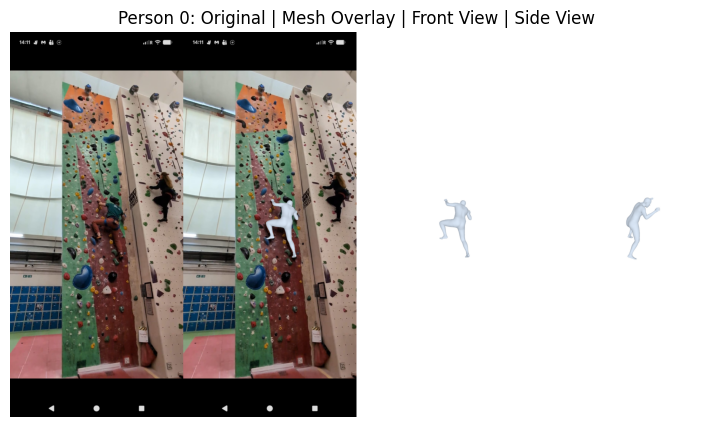

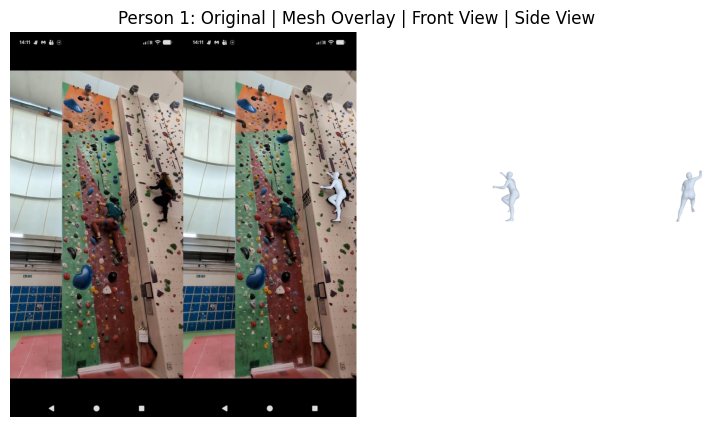

In [5]:
if outputs:
    mesh_results = visualize_3d_mesh(img_cv2, outputs, estimator.faces)
    
    # Display results
    for i, combined_img in enumerate(mesh_results):
        combined_rgb = cv2.cvtColor(combined_img, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(20, 5))
        plt.imshow(combined_rgb)
        plt.title(f'Person {i}: Original | Mesh Overlay | Front View | Side View')
        plt.axis('off')
        plt.show()
else:
    print("No people detected for 3D mesh visualization")

## 5. Save 3D Mesh Files and Results

In [6]:
if outputs:
    # Get image name without extension
    image_name = os.path.splitext(os.path.basename(image_path))[0]
    
    # Create output directory
    output_dir = f"output/{image_name}"

    # Save all results (PLY meshes, overlay images, bbox images)
    ply_files = save_mesh_results(img_cv2, outputs, estimator.faces, output_dir, image_name)
    
    print(f"\n=== Saved Results for {image_name} ===")
    print(f"Output directory: {output_dir}")
    print(f"Number of PLY files created: {len(ply_files)}")
    
else:
    print("No results to save - no people detected")

Saved focal length: output/diego/diego_focal_length.json
Saved mesh: output/diego/diego_mesh_000.ply
Saved overlay: output/diego/diego_overlay_000.png
Saved bbox: output/diego/diego_bbox_000.png
Saved mesh: output/diego/diego_mesh_001.ply
Saved overlay: output/diego/diego_overlay_001.png
Saved bbox: output/diego/diego_bbox_001.png

=== Saved Results for diego ===
Output directory: output/diego
Number of PLY files created: 2


# video mesh

In [9]:
import cv2
import numpy as np
import warnings
import sys
import os
from tqdm import tqdm

warnings.filterwarnings('ignore')

class SuppressPrints:
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')
        return self
    
    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout

# Extract frames
video_path = "images/diego.mp4"
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)

frames = []
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    if frame_idx % 5 == 0:
        frames.append(frame)
    frame_idx += 1

cap.release()
print(f"Extracted {len(frames)} frames (expected ~{int(cap.get(cv2.CAP_PROP_FRAME_COUNT) / 5)})")

frames_rgb = [cv2.cvtColor(f, cv2.COLOR_BGR2RGB) for f in frames]

# Process in batches
batch_size = 8
all_outputs = []

for i in tqdm(range(0, len(frames_rgb), batch_size), desc="Processing batches"):
    batch = frames_rgb[i:i+batch_size]
    
    for frame_rgb in batch:
        with SuppressPrints():
            outputs = estimator.process_one_image(frame_rgb)
        all_outputs.append(outputs if outputs else [])

# Tracking
tracked_outputs = []
prev_pos = None
max_dist = 150

for outputs in tqdm(all_outputs, desc="Tracking"):
    if outputs:
        if prev_pos is None:
            selected = outputs[0]
        else:
            selected = min(outputs, key=lambda p: np.linalg.norm(
                p['pred_vertices'].mean(axis=0)[:2] - prev_pos))
            if np.linalg.norm(selected['pred_vertices'].mean(axis=0)[:2] - prev_pos) > max_dist:
                tracked_outputs.append([])
                continue
        
        prev_pos = selected['pred_vertices'].mean(axis=0)[:2]
        tracked_outputs.append([selected])
    else:
        tracked_outputs.append([])

print(f"Tracked: {sum(1 for o in tracked_outputs if o)}/{len(frames)}")
all_outputs = tracked_outputs

Extracted 292 frames (expected ~0)


Tracking: 100%|█████████████████████████████████████████████████████████████████████| 292/292 [00:00<00:00, 2223.81it/s]

Tracked: 278/292


In [14]:
def create_mesh_video(frames, all_outputs, estimator, fps, output_path=None, frame_skip=5):
    """
    Create video with mesh overlay from processed frames.
    
    Args:
        frames: List of BGR frames
        all_outputs: List of SAM 3D Body outputs per frame
        estimator: SAM 3D Body estimator (for faces)
        fps: Original video FPS
        output_path: Path for output video (default: auto-generated)
        frame_skip: Frame skip used during extraction (default: 5)
    
    Returns:
        Path to created video
    """
    import subprocess
    import os
    import shutil
    from tqdm import tqdm
    import cv2
    
    # Set default output path
    if output_path is None:
        output_path = os.path.expanduser("~/SAM-mesh/sam-3d-body/notebook/output/mesh_video.mp4")
    
    # Setup frame directory
    output_dir = os.path.splitext(output_path)[0] + "_frames"
    
    # Clear old frames
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.makedirs(output_dir, exist_ok=True)
    
    # Save frames
    for i, (frame, outputs) in enumerate(tqdm(zip(frames, all_outputs), 
                                              total=len(frames), 
                                              desc="Saving frames")):
        if outputs:
            mesh_vis = visualize_3d_mesh(frame, outputs, estimator.faces)
            cv2.imwrite(f"{output_dir}/frame_{i:04d}.jpg", mesh_vis[0])
        else:
            cv2.imwrite(f"{output_dir}/frame_{i:04d}.jpg", frame)
    
    # Create video
    print("\nCreating video with ffmpeg...")
    playback_fps = fps / frame_skip
    
    subprocess.run([
        'ffmpeg', '-y', '-loglevel', 'error',
        '-framerate', str(playback_fps),
        '-i', f'{output_dir}/frame_%04d.jpg',
        '-c:v', 'libx264', '-crf', '23', '-pix_fmt', 'yuv420p',
        output_path
    ], check=True)
    
    print(f"Video created: {output_path}")
    return output_path



In [17]:

video_path = create_mesh_video(
    frames,       # List of BGR frames
    all_outputs,  # List of SAM 3D Body outputs per frame
    estimator,    # SAM 3D Body estimator (for faces)
    fps,          # Original-video FPS
    output_path = "~/SAM-mesh/sam-3d-body/notebook/output/mesh_chorevideo.mp4",  # Path for output video (default: auto-generated)
    frame_skip = 5)   #: Frame skip used during extraction (default: 5)frames, all_outputs, estimator, fps)


Saving frames: 100%|██████████████████████████████████████████████████████████████████| 292/292 [02:38<00:00,  1.85it/s]



Creating video with ffmpeg...
Video created: ~/SAM-mesh/sam-3d-body/notebook/output/mesh_chorevideo.mp4


# with person selection

In [11]:
import cv2
import numpy as np
import warnings
import sys
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

class SuppressPrints:
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')
        return self
    
    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout

# Extract frames - FIXED: removed double read
video_path = "images/diego.mp4"
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)

frames = []
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    if frame_idx % 5 == 0:
        frames.append(frame)
    frame_idx += 1

cap.release()
print(f"Extracted {len(frames)} frames")

# Show first frame and let user choose
frame_rgb = cv2.cvtColor(frames[0], cv2.COLOR_BGR2RGB)
with SuppressPrints():
    first_outputs = estimator.process_one_image(frame_rgb)

if len(first_outputs) > 1:
    print(f"\n{len(first_outputs)} people detected in first frame")
    vis = visualize_2d_results(frames[0], first_outputs, visualizer)
    
    fig, axes = plt.subplots(1, len(vis), figsize=(6*len(vis), 6))
    if len(vis) == 1:
        axes = [axes]
    for idx, (img, ax) in enumerate(zip(vis, axes)):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(f'Person {idx}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    person_idx = int(input(f"Which person to track? (0-{len(first_outputs)-1}): "))
    initial_person = first_outputs[person_idx]
else:
    print("1 person detected - auto-selecting")
    initial_person = first_outputs[0]



Extracted 292 frames
1 person detected - auto-selecting


In [ ]:
# Convert frames to RGB
frames_rgb = [cv2.cvtColor(f, cv2.COLOR_BGR2RGB) for f in frames]

# Process in batches
batch_size = 8
all_outputs = []

for i in tqdm(range(0, len(frames_rgb), batch_size), desc="Processing batches"):
    batch = frames_rgb[i:i+batch_size]
    
    for frame_rgb in batch:
        with SuppressPrints():
            outputs = estimator.process_one_image(frame_rgb)
        all_outputs.append(outputs if outputs else [])

# Tracking with initial person
tracked_outputs = []
prev_pos = initial_person['pred_vertices'].mean(axis=0)[:2]
tracked_outputs.append([initial_person])
max_dist = 150

for outputs in tqdm(all_outputs[1:], desc="Tracking"):
    if outputs:
        selected = min(outputs, key=lambda p: np.linalg.norm(
            p['pred_vertices'].mean(axis=0)[:2] - prev_pos))
        
        if np.linalg.norm(selected['pred_vertices'].mean(axis=0)[:2] - prev_pos) < max_dist:
            prev_pos = selected['pred_vertices'].mean(axis=0)[:2]
            tracked_outputs.append([selected])
        else:
            tracked_outputs.append([])
    else:
        tracked_outputs.append([])

print(f"Tracked: {sum(1 for o in tracked_outputs if o)}/{len(frames)}")
all_outputs = tracked_outputs

# Create video
import subprocess

output_dir = os.path.expanduser("~/SAM-mesh/sam-3d-body/notebook/output/mesh_frames")
os.makedirs(output_dir, exist_ok=True)

for i, (frame, outputs) in enumerate(tqdm(zip(frames, all_outputs), total=len(frames), desc="Saving frames")):
    if outputs:
        mesh_vis = visualize_3d_mesh(frame, outputs, estimator.faces)
        cv2.imwrite(f"{output_dir}/frame_{i:04d}.jpg", mesh_vis[0])
    else:
        cv2.imwrite(f"{output_dir}/frame_{i:04d}.jpg", frame)

print("\nCreating video with ffmpeg...")
output_video = os.path.expanduser("~/SAM-mesh/sam-3d-body/notebook/output/mesh_video.mp4")
subprocess.run([
    'ffmpeg', '-y', '-framerate', str(fps/5),
    '-i', f'{output_dir}/frame_%04d.jpg',
    '-c:v', 'libx264', '-crf', '23', '-pix_fmt', 'yuv420p',
    output_video
])
print(f"Video: {output_video}")

In [ ]:
# Save frames as images first
output_dir = os.path.expanduser("~/SAM-mesh/sam-3d-body/notebook/output/mesh_frames")
os.makedirs(output_dir, exist_ok=True)

print("Saving frames...")
for i, (frame, outputs) in enumerate(zip(frames, all_outputs)):
    if outputs:
        mesh_vis = visualize_3d_mesh(frame, outputs, estimator.faces)
        cv2.imwrite(f"{output_dir}/frame_{i:04d}.jpg", mesh_vis[0])
    else:
        cv2.imwrite(f"{output_dir}/frame_{i:04d}.jpg", frame)
    
    if i % 20 == 0:
        print(f"Saved {i}/{len(frames)}")

print("\nCreating video with ffmpeg...")
# Create video with H.264 compression
output_video = os.path.expanduser("~/SAM-mesh/sam-3d-body/notebook/output/mesh_video.mp4")
cmd = [
    'ffmpeg', '-y',
    '-framerate', str(fps/5),
    '-i', f'{output_dir}/frame_%04d.jpg',
    '-c:v', 'libx264',
    '-crf', '23',  # Quality (lower = better, 18-28 typical)
    '-pix_fmt', 'yuv420p',
    output_video
]

subprocess.run(cmd)
print(f"Video created: {output_video}")